# VGG
## 简介
由牛津大学视觉几何组（Visual Geometry Group）提出。主要特点是使用小卷积核（3x3）堆叠成块，使用块构建深度网络。

![VGG](./images/VGG.png)

## VGG 块
一个 VGG 块有若干个卷积层和一个池化层收尾。
- n 个 3x3 卷积核（步幅 1，填充 1）
- 2x2 最大池化（步幅 2）

多个 3x3 卷积核堆叠可以扩大感受野，并且比大卷积核的非线性拟合能力更强。

![VGG 块](./images/VGG_block.jpg)

VGG 用块堆叠的方式改进 AlexNet 一些略显随意的设计

![AlexNet 和 VGG](./images/vgg.svg)


## 实现


In [1]:
import torch
from torch import nn
import torchinfo
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


### VGG 块


In [2]:
def vgg_block(num_convs: int, in_channels: int, out_channels: int):
    """VGG 块
    :param num_convs: 卷积层数
    :param in_channels: 输入通道数
    :param out_channels: 输出通道数
    """
    layers = []
    # 逐层堆叠卷积层和 ReLU
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        # 第一次循环后，输入通道数变为输出通道数
        in_channels = out_channels
    # 池化层收尾
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

In [3]:
def vgg(conv_arch: list[tuple[int, int]], in_channels: int=1) -> nn.Sequential:
    """VGG 网络
    :param conv_arch: 卷积层架构，列表中每个元素是一个元组 (num_convs, out_channels)
    :param in_channels: 输入通道数
    :return: VGG 网络
    """
    # 固定 5 块，正好把 224x224 的图像缩小到 7x7
    assert len(conv_arch) == 5, "VGG 网络必须有 5 个卷积块"
    conv_blks = [] # 存储 VGG 块
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        # 下一层的输入通道数 是 当前的输出通道数
        in_channels = out_channels
    return nn.Sequential(
        *conv_blks, # 堆叠所有 VGG 块
        nn.Flatten(), # 7x7 的特征图展平为向量
        # 三个全连接层
        nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 10)
    )

VGG-11 的架构，每一块高宽减半，通道数翻倍


In [4]:
conv_arch = [(1, 64),
             (1, 128),
             (2, 256),
             (2, 512),
             (2, 512)]
net = vgg(conv_arch, in_channels=1)
torchinfo.summary(net, input_size=(1, 1, 224, 224), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Sequential                               [1, 1, 224, 224]          [1, 10]                   --
├─Sequential: 1-1                        [1, 1, 224, 224]          [1, 64, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 1, 224, 224]          [1, 64, 224, 224]         640
│    └─ReLU: 2-2                         [1, 64, 224, 224]         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-3                    [1, 64, 224, 224]         [1, 64, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 112, 112]         [1, 128, 56, 56]          --
│    └─Conv2d: 2-4                       [1, 64, 112, 112]         [1, 128, 112, 112]        73,856
│    └─ReLU: 2-5                         [1, 128, 112, 112]        [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-6                    [1, 128, 112, 112]        [1, 128, 56, 56]          --
├─Sequential: 1-3             

太大了，减少一些通道数来训练


In [9]:
ratio = 4
small_arch = [(convs, channels // ratio) for (convs, channels) in conv_arch]
net = vgg(small_arch, in_channels=1)

loss 0.167, train acc 0.938, test acc 0.920
6058.3 examples/sec on cuda:0


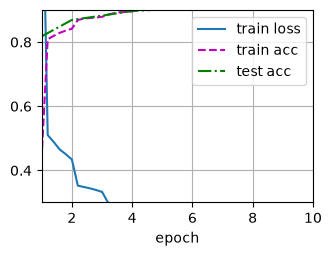

In [11]:
lr = 0.09
num_epochs = 10
batch_size = 128
train_iter, test_iter = util.data.load_data_fashion_mnist(batch_size=batch_size, resize=224)
util.train.train_ch6(net, train_iter, test_iter, num_epochs, lr, device=util.try_gpu())

In [13]:
torch.save(net.state_dict(), "./models/VGG.pth")